In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

### Which Machine Learning algo are Sensitive to outliers.
* Naive Bayes Classifier --------------------------It's not sensitive to outliers.
* SVM -------------------------------------------------It's not sensitive to outliers.
* Linear Regression -------------------------------It's sensitive to outliers.
* Logistic Regression ----------------------------It's Sensitive to outliers.
* Decision Tree Classifier or Regressor -----It's not Sensitive to Outliers.
* Ensemble (RF, XGboost, GB) ---------------It's not Sensitive to Outliers.
* KNN -----------------------------------------------It's Not Sensitive to Outliers.
* Kmeans ------------------------------------------It's Sensitive to Outliers.
* Hierarichal --------------------------------------It's Sensitive to Outliers.
* PCA ----------------------------------------------It's Sensitive to Oultiers.
* Neural Network --------------------------------It's Sensitive to Outliers.
* DBSCAN ----------------------------------------It's  Sensitive to Outliers.


* All the UNsupervised learing all are affected by outliers :( !


In [2]:
data = pd.read_csv('train_titanic.csv')

In [3]:
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
data.Age.isnull().sum()

177

C:\Users\aravi\anaconda3\envs\tensflow\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


<AxesSubplot:xlabel='Age', ylabel='Density'>

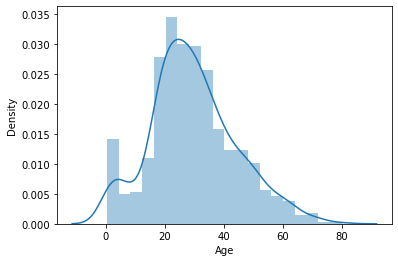

In [5]:
sns.distplot(data.Age.dropna())

# Finding Outliers for Gaussian Distribution

sns.distplot(data.Age.fillna(100))

<AxesSubplot:>

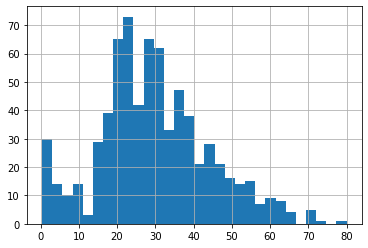

In [6]:
data.Age.hist(bins = 30)

* Whenver we have a gaussian Distribution in our data set there is a differnt approach to find the outliers.

<AxesSubplot:ylabel='Age'>

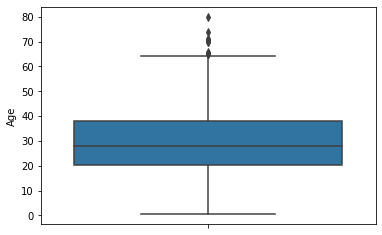

In [7]:
sns.boxplot(y = data.Age)

* If we have a normal distribution in our data, we use differnt method to find the outliers.

* Assuming Age follows the normal distribution we will calculate the boundries with differentiates 
the outliers. 

In [8]:
upper_boundary = data.Age.mean() + 3 * data.Age.std()

In [9]:
lower_boundary = data.Age.mean() - 3 * data.Age.std()

In [10]:
# anything apart from this, that is outlier for normal distribution.

# Finding Outliers for Skewness

<AxesSubplot:>

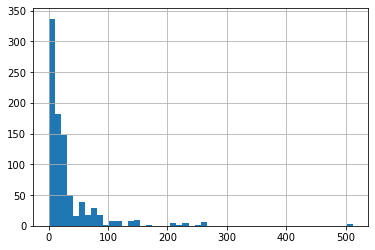

In [11]:
data.Fare.hist(bins = 50)
# This is Right Skewed right !

<AxesSubplot:ylabel='Fare'>

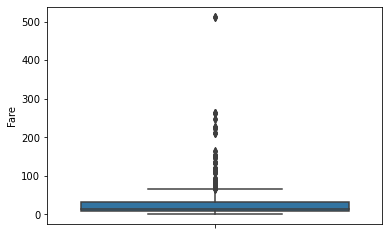

In [12]:
sns.boxplot(y = data.Fare)

In [13]:
IQR = data.Fare.quantile(0.75) - data.Fare.quantile(0.25)

In [14]:
lower_bridge = data.Fare.quantile(0.25) - (IQR * 1.5)
higher_bridge = data.Fare.quantile(0.75) + (IQR * 1.5)

In [15]:
# For finding the Extreme Outliers
lower_bridge = data.Fare.quantile(0.25) - (IQR * 3)
higher_bridge = data.Fare.quantile(0.75) + (IQR * 3)

In [16]:
# anthing apart from this, that is considerd to be outlier for both right skewed and left skewed.

## Handling Outliers.

In [17]:
# for age have upper bound of 73.

df = data.copy()
df.loc[data['Age'] > 73] = 73 # I am just replacing the higger values into the 73.

In [18]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [19]:
# for fare have upper bound of 100

df.loc[data['Fare'] > 100] = 100

<AxesSubplot:>

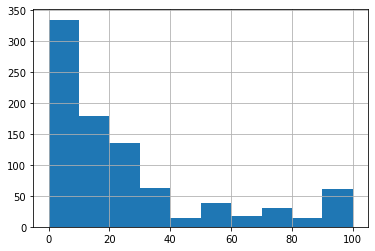

In [20]:
df.Fare.hist()
# see max is 100 there is no outliers. in the data.

In [22]:
X = df[['Age','Fare']]
y = df['Survived']

In [23]:
X = X.fillna(0)
X = X.astype(int)

In [24]:
from sklearn.model_selection import train_test_split

In [ ]:
X = df[['Age','Fare']]
y = df['Survived']

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [26]:
from sklearn.linear_model import LogisticRegression

In [29]:
lr = LogisticRegression()
lr.fit(X_train, y_train)
pred = lr.predict(X_test)
pred1 = lr.predict_proba(X_test)
from sklearn.metrics import accuracy_score, roc_auc_score
print(accuracy_score(y_test, pred))
#print(roc_auc_score(y_test, pred1[:,1]))

0.7016949152542373


C:\Users\aravi\anaconda3\envs\tensflow\lib\site-packages\sklearn\linear_model\_logistic.py:765: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  extra_warning_msg=_LOGISTIC_SOLVER_CONVERGENCE_MSG)


In [30]:
from sklearn.ensemble import RandomForestClassifier
lr = RandomForestClassifier()
lr.fit(X_train, y_train)
pred = lr.predict(X_test)
pred1 = lr.predict_proba(X_test)
from sklearn.metrics import accuracy_score, roc_auc_score
print(accuracy_score(y_test, pred))

0.6915254237288135
